# Local ROM Stability Check

Build a FOM trajectory from a chosen initial condition, construct POD/DEIM ROMs, run the true-nonlinearity ROM, and inspect capture/trajectory/modes before training a neural ROM.

In [52]:
using LinearAlgebra
using SparseArrays
using ComponentArrays
using OrdinaryDiffEq
using Plots


include(joinpath(@__DIR__, "..", "..", "src", "HPC", "Simulations", "integration_AC_hpc.jl"))
include(joinpath(@__DIR__, "..", "..", "src", "HPC", "Tools", "hpc_common.jl"))
include(joinpath(@__DIR__, "..", "..", "src", "HPC", "Simulations", "ROM_opt_AC_hpc.jl"))
include(joinpath(@__DIR__, "..", "..", "src", "Visualizations", "optimization_visualizations.jl"))

[package-load] Loading LinearAlgebra
[package-load] Loaded LinearAlgebra
[package-load] Loading SparseArrays
[package-load] Loaded SparseArrays
[package-load] Loading Random
[package-load] Loaded Random
[package-load] Loading ComponentArrays
[package-load] Loaded ComponentArrays
[package-load] Loading LinearSolve
[package-load] Loaded LinearSolve
[package-load] Loading OrdinaryDiffEq
[package-load] Loaded OrdinaryDiffEq
[package-load] Loading OrdinaryDiffEqSDIRK
[package-load] Loaded OrdinaryDiffEqSDIRK
[package-load] Loading OrdinaryDiffEqLowOrderRK
[package-load] Loaded OrdinaryDiffEqLowOrderRK
[package-load] Loading SciMLSensitivity
[package-load] Loaded SciMLSensitivity
[package-load] Loading ADTypes
[package-load] Loaded ADTypes
[package-load] Loading Zygote
[package-load] Loaded Zygote
[package-load] Loading Optimization
[package-load] Loaded Optimization
[package-load] Loading OptimizationOptimisers
[package-load] Loaded OptimizationOptimisers
[package-load] Loading Optimization

visualize_FOM

## Parameters

In [116]:
N = 256
L = 1.0
ε2 = 1e-2
k = 1.0
tspan = (0.0, 2.0)
reference_dt_factor = 0.5
dimension = 2
boundary_condition = "periodic"
N_obs = 100
h = 8
seed = 1

r = 4
m = 4

interface_width = sqrt(2ε2)
initial_condition_examples = [
    (name="default", u0=nothing),

    (name="2d circle drop", u0=(x, y) -> tanh((sqrt((x - 0.5)^2 + (y - 0.5)^2) - 0.23) / interface_width)),
    (name="2d offcenter drop", u0=(x, y) -> tanh((sqrt((x - 0.35)^2 + (y - 0.58)^2) - 0.18) / interface_width)),

    
    (name="2d one-direction tanh front", u0=(x, y) -> tanh((x - 0.5) / interface_width)),
   
    (name="2d annulus", u0=(x, y) -> max(
        tanh((sqrt((x - 0.5)^2 + (y - 0.5)^2) - 0.30) / interface_width),
        tanh((0.15 - sqrt((x - 0.5)^2 + (y - 0.5)^2)) / interface_width),
    )),
    (name="2d soft bleedout patch and static slab", u0=(x, y) ->
    0.5 * (1 - tanh((x - 0.50) / (2.0interface_width))) *
        (0.55sin(6π * x / L) * sin(4π * y / L) +
         0.20sin(10π * x / L + 0.7) * sin(2π * y / L)) +
    0.5 * (1 + tanh((x - 0.50) / (2.0interface_width))) *
        tanh((x - 0.72) / (1.2interface_width))
),
    (name="2d sin xy", u0=(x, y) -> sin(2π * x / L) * sin(2π * y / L)),
    (name="2d high frequency x sine", u0=(x, y) -> sin(3π * x / L)),
    ];

initial_condition_2d_examples = filter(ic -> startswith(ic.name, "2d "), initial_condition_examples)


7-element Vector{NamedTuple{(:name, :u0)}}:
 (name = "2d circle drop", u0 = var"#1226#1227"())
 (name = "2d offcenter drop", u0 = var"#1228#1229"())
 (name = "2d one-direction tanh front", u0 = var"#1230#1231"())
 (name = "2d annulus", u0 = var"#1232#1233"())
 (name = "2d soft bleedout patch and static slab", u0 = var"#1234#1235"())
 (name = "2d sin xy", u0 = var"#1236#1237"())
 (name = "2d high frequency x sine", u0 = var"#1238#1239"())

## Functions

In [ ]:
function materialize_initial_condition(u0; N=256, L=1.0, ε2=1e-2, dimension=1, boundary_condition="homogeneous_dirichlet")
    dim = validate_ac_dimension(dimension)
    if isnothing(u0) || !(u0 isa Function)
        return u0
    end
    grid = ac_grid(N, L, boundary_condition)
    x = grid.x
    if dim == 1
        return Float64[u0(xi) for xi in x]
    end
    return Float64[u0(x[i], x[j]) for i in 1:N, j in 1:N]
end

function plot_initial_conditions(initial_conditions; N=256, L=1.0, ε2=1e-2, dimension=1, boundary_condition="homogeneous_dirichlet", show_colorbar=false)
    grid = ac_grid(N, L, boundary_condition)
    dim = validate_ac_dimension(dimension)
    if dim == 1
        p = plot(xlabel="x", ylabel="u0", title="Initial conditions")
        for item in initial_conditions
            values = isnothing(item.u0) ? default_ac_initial_condition(N, L, ε2, dim, boundary_condition) : materialize_initial_condition(item.u0; N, L, ε2, dimension=dim, boundary_condition)
            plot!(p, grid.x, values; label=item.name)
        end
        return p
    end
    plots = Any[]
    for item in initial_conditions
        values = isnothing(item.u0) ? default_ac_initial_condition(N, L, ε2, dim, boundary_condition) : materialize_initial_condition(item.u0; N, L, ε2, dimension=dim, boundary_condition)
        push!(plots, heatmap(grid.x, grid.x, reshape(values, N, N); title=item.name, aspect_ratio=:equal, clims=show_colorbar ? (-1, 1) : nothing, colorbar=show_colorbar))
    end
    return plot(plots...; layout=(1, length(plots)), size=(350 * length(plots), 320))
end

function run_fom_reference(; N=256, L=1.0, ε2=1e-2, k=1.0, tspan=(0.0, 2.0), reference_dt_factor=0.5, u0=nothing, dimension=1, boundary_condition="homogeneous_dirichlet")
    tspan[1] == 0.0 || error("build_ac_reference expects tspan to start at 0.0")
    u₀ = materialize_initial_condition(u0; N, L, ε2, dimension, boundary_condition)
    ref = build_ac_reference(; N, L, ε2, k, tfinal=tspan[2], reference_dt_factor, dimension, boundary_condition, u₀)
    A = get_lap_ac_matrix(N, ε2, ref.Δx, ref.dimension, ref.boundary_condition)
    return merge(ref, (; sol=ref.u_ref, A))
end

function build_stability_rom(fom, r::Integer, m::Integer; N_obs=100, h=8, seed=1)
    prob = prepare_ROM_optimization(fom.A, fom.u_ref, r, m; N_obs, h, seed, dimension=fom.dimension, boundary_condition=fom.boundary_condition)
    return (; prob, rom=prob.f.f.data.rom)
end

function rhs_true_rom!(du, u, p, t)
    z = p.rom.Up * u
    fz = .-p.k .* (z .^ 3 .- z)
    du .= p.rom.Ã * u + p.rom.B * fz
    return nothing
end

function run_stability_rom(fom, rom_bundle; alg=TRBDF2())
    rom = rom_bundle.rom
    u0_rom = rom.U' * fom.u_ref.prob.u0
    p = (; rom, k=fom.u_ref.prob.p.k)
    prob = ODEProblem(rhs_true_rom!, u0_rom, fom.u_ref.prob.tspan, p)
    sol = solve(prob, alg; saveat=fom.u_ref.t)
    reconstructed = rom.U * hcat(sol.u...)
    return (; sol, reconstructed)
end

capture_ratio(s, n) = sum(abs2, s[1:min(n, length(s))]) / sum(abs2, s)

function capture_table(fom; rs=[2, 4, 8, 10, 15, 20], ms=[2, 4, 8, 10, 15, 20])
    max_r = minimum((maximum(rs), length(fom.u_ref.u), length(fom.u_ref.u[1])))
    max_m = minimum((maximum(ms), length(fom.u_ref.u), length(fom.u_ref.u[1])))
    base = build_stability_rom(fom, max_r, max_m).rom
    rows = NamedTuple[]
    for r_i in rs, m_i in ms
        push!(rows, (;
            m=m_i,
            r=r_i,
            state_capture=capture_ratio(base.state_singular_values, r_i),
            nonlinear_capture=capture_ratio(base.nonlinear_singular_values, m_i),
        ))
    end
    return rows
end



capture_table (generic function with 1 method)

## Initial Conditions

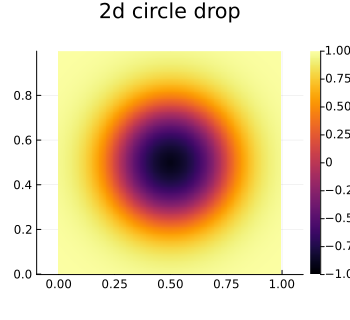

k=1
k=2
k=3
k=4
k=5
k=6
k=7


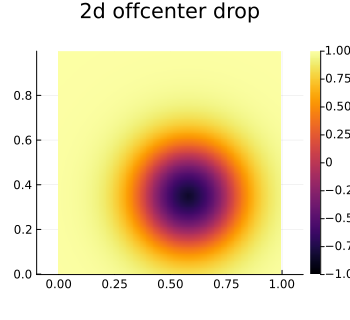

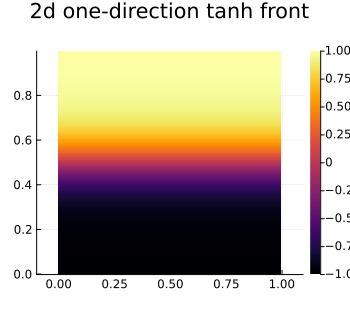

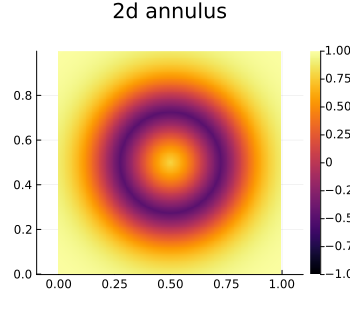

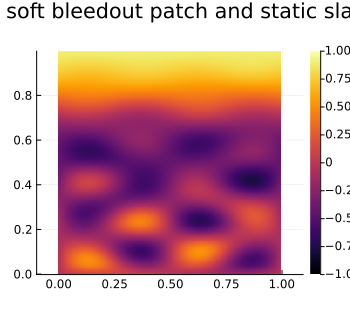

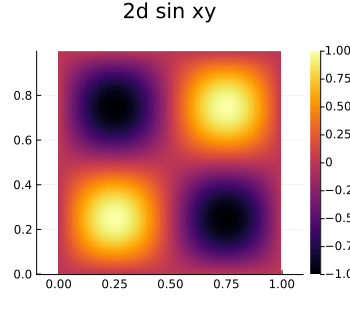

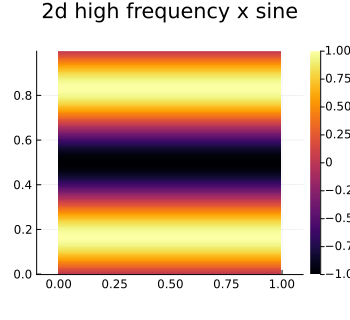

In [117]:
for k in 1:length(initial_condition_2d_examples)
    println("k=$k")
    selected_initial_condition_2d_index = k
    selected_initial_condition = initial_condition_2d_examples[selected_initial_condition_2d_index]
    display(
        plot_initial_conditions([selected_initial_condition];
         N, L, ε2, dimension, boundary_condition, show_colorbar = true)
         )
end

## Run FOM, Build ROM, Run ROM

In [119]:
selected_initial_condition = initial_condition_2d_examples[7]

u0 = selected_initial_condition.u0
fom = run_fom_reference(; N, L, ε2, k, tspan, reference_dt_factor, u0, dimension, boundary_condition)
println("Ran FOM reference")
rom = build_stability_rom(fom, r, m; N_obs, h, seed)
println("Built ROM")
rom_run = run_stability_rom(fom, rom);
println("Ran ROM ")


Reference solve: N=256, Δx=0.00390625, Δt=0.0003814697265625, saved_times=500
Ran FOM reference
Built ROM
Ran ROM 


## Singular-Value Capture

In [57]:
# capture_table(fom; rs=[2, 4, 8, 10, 15, 20], ms=[2, 4, 8, 10, 15, 20])

## Trajectory

┌ Info: Saved animation to /Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_rom_overlay_2d.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156



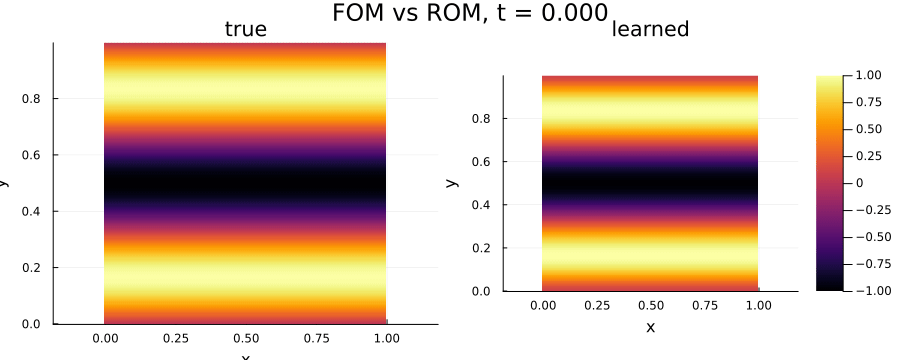

(overlay_path = "/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_rom_overlay_2d.gif",)

In [120]:
trajectory_gifs(fom, rom_run; out_dir=joinpath(@__DIR__, "rom_stability_gifs"), max_frames=15, fps=1, show_colorbar = true)

In [77]:
true_u = hcat(fom.u_ref.u...)
rom_u = rom_run.reconstructed

true_change = [maximum(abs.(true_u[:, j] .- true_u[:, 1])) for j in axes(true_u, 2)]
rom_change = [maximum(abs.(rom_u[:, j] .- rom_u[:, 1])) for j in axes(rom_u, 2)]

@show size(true_u)
@show size(rom_u)
@show length(fom.u_ref.t)
@show extrema(true_u)
@show extrema(rom_u)
@show maximum(true_change)
@show maximum(rom_change)
@show true_change[1:10:end]

size(true_u) = (65536, 500)
size(rom_u) = (65536, 500)
length(fom.u_ref.t) = 500
extrema(true_u) = (-0.9999985572927353, 0.9999983887556901)
extrema(rom_u) = (-1.1606769952377887, 1.160619461215456)
maximum(true_change) = 1.3591492258540685
maximum(rom_change) = 1.352524718949196
true_change[1:10:end] = [0.0, 0.9624992292825997, 0.9780742569486038, 0.9849004529401618, 0.9954788289957982, 1.016118593058163, 1.0347092875604813, 1.051222806368542, 1.06607284746062, 1.0795080486464537, 1.091780591961144, 1.1031944774739157, 1.1138275261170838, 1.123778525490065, 1.1332756465947775, 1.1422711165981125, 1.1508886879185707, 1.159183191148657, 1.1671608863229685, 1.1749163086894283, 1.182421989394541, 1.1897415750476252, 1.1968910925255836, 1.2038417398296426, 1.210716017568169, 1.217400619038426, 1.223998878622267, 1.2304950571108262, 1.2368445058383488, 1.2431497145687818, 1.2493639507714092, 1.2554595865559635, 1.2614976688336519, 1.2674904466050492, 1.2733830779671993, 1.2791808241510383, 

50-element Vector{Float64}:
 0.0
 0.9624992292825997
 0.9780742569486038
 0.9849004529401618
 0.9954788289957982
 1.016118593058163
 1.0347092875604813
 1.051222806368542
 1.06607284746062
 1.0795080486464537
 ⋮
 1.3129066270855325
 1.318324151470819
 1.323671389689081
 1.3289486220181344
 1.334205250628193
 1.3394220561570038
 1.344572432135526
 1.3496587202271582
 1.3546815530534702

## Modes

In [60]:
plot_rom_modes(fom, rom, n_state=10, n_deim=10)

BoundsError: BoundsError: attempt to access 65536×4 Matrix{Float64} at index [1:65536, 5]